# AnemoScan: Ai - Based Early Detection Of Anemia From Nail & Conjunctiva Images
## Type Classifier (Conjunctiva vs Nails)
- This notebook presents a deep learning model developed to classify images into two categories: conjunctiva and nails. The model is built using transfer learning with MobileNetV2 and follows a complete pipeline including data preprocessing, training, and evaluation.

## 1. Import Required Libraries
- In this section, we import all necessary libraries for data handling, preprocessing, model building, training, evaluation, and visualization.

In [3]:
import os
import shutil
import random
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

## 2. Rename Dataset Images
- In this section, all images are renamed systematically to ensure consistency and avoid duplication. Each image is assigned a unique name based on its category (conjunctiva or nails) and an incremental index.

In [5]:
def rename_images(base_path):
    folders = ['Conjunctiva', 'Nails']

    for folder in folders:
        folder_path = os.path.join(base_path, folder)
        files = sorted(os.listdir(folder_path))

        count = 1

        for file in files:
            if not file.lower().endswith(('.png', '.jpg', '.jpeg')):
                continue

            old_path = os.path.join(folder_path, file)

            if folder.lower() == 'conjunctiva':
                prefix = 'conj'
            else:
                prefix = 'nail'

            new_name = f'{prefix}_{count:05d}.jpg'
            new_path = os.path.join(folder_path, new_name)

            os.rename(old_path, new_path)
            count += 1

    print('Renaming completed successfully!')

base_path = r'D:\Spring 2025-2026\TM471B\AnemoScan\Data\Type_Classifier'
rename_images(base_path)

Renaming completed successfully!


## 3. Create Dataset Structure & Split Dataset into Train, Validation, and Test Sets
 - In this section, the required folder structure for training, validation, and testing is created. Each split contains separate folders for conjunctiva and nails images to support classification.
 - In this section, the dataset is split into training, validation, and testing sets using predefined ratios. This ensures proper model evaluation and prevents data leakage.

In [7]:
def create_folders(base_path):
    for split in ['train', 'val', 'test']:
        for cls in ['Conjunctiva', 'Nails']:
            path = os.path.join(base_path, split, cls)
            os.makedirs(path, exist_ok = True)


def split_data(base_path, split_ratio = (0.7, 0.15, 0.15)):
    classes = ['Conjunctiva', 'Nails']

    for class_name in classes:
        src = os.path.join(base_path, class_name)

        images = [img for img in os.listdir(src)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

        random.shuffle(images)

        train_split = int(len(images) * split_ratio[0])
        val_split = int(len(images) * (split_ratio[0] + split_ratio[1]))

        train_imgs = images[ : train_split]
        val_imgs = images[train_split : val_split]
        test_imgs = images[val_split : ]

        for split_name, split_imgs in zip(
            ['train', 'val', 'test'],
            [train_imgs, val_imgs, test_imgs]
        ):
            for img in split_imgs:
                src_path = os.path.join(src, img)
                dest_path = os.path.join(base_path, split_name, class_name, img)

                if not os.path.exists(dest_path):
                    shutil.copy(src_path, dest_path)

    print('Data split completed!')

base_path = r'D:\Spring 2025-2026\TM471B\AnemoScan\Data\Type_Classifier'

create_folders(base_path)
split_data(base_path)

print('Type classifier splitting done!')

Data split completed!
Type classifier splitting done!


## 4. Data Preprocessing and Augmentation
- In this section, image data generators are defined. Training data is augmented using transformations such as rotation, flipping, and zooming, while validation and test data are only rescaled.

In [9]:
base_dir = r'D:\Spring 2025-2026\TM471B\AnemoScan\Data\Type_Classifier'

train_dir = base_dir + r'\train'
val_dir = base_dir + r'\val'
test_dir = base_dir + r'\test'

In [10]:
img_size = (224, 224)
batch_size = 32

# Training (WITH augmentation)
train_datagen = ImageDataGenerator(
    rescale = 1. / 255,
    rotation_range = 10,
    horizontal_flip = True,
    zoom_range = 0.1
)

# Validation (NO augmentation)
val_test_datagen = ImageDataGenerator(rescale = 1. / 255)

## 5. Load Data using Generators
- In this section, the dataset is loaded using directory-based generators, which automatically assign labels based on folder names and prepare batches for training and evaluation.

In [12]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'binary'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'binary'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size = img_size,
    batch_size = batch_size,
    class_mode = 'binary',
    shuffle = False  # IMPORTANT for evaluation
)

Found 6614 images belonging to 2 classes.
Found 1418 images belonging to 2 classes.
Found 1418 images belonging to 2 classes.


In [13]:
print(train_generator.class_indices)

{'Conjunctiva': 0, 'Nails': 1}


## 6. Build the Model using Transfer Learning
- In this section, a pre-trained MobileNetV2 model is used as a feature extractor. The base model is frozen, and a custom classification head is added to adapt it for binary classification.

In [15]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape = (224, 224, 3),
    include_top = False,
    weights = 'imagenet'
)

In [16]:
base_model.trainable = False

In [17]:
x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)

x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.Dense(128, activation = 'relu')(x)

x = tf.keras.layers.Dropout(0.5)(x)

output = tf.keras.layers.Dense(1, activation = 'sigmoid')(x)

In [18]:
model = tf.keras.Model(inputs = base_model.input, outputs = output)

## 7. Compile the Model
- In this section, the model is compiled using the Adam optimizer, binary cross-entropy loss function, and accuracy as the evaluation metric.

In [20]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

## 8. Train the Model
- In this section, the model is trained on the training dataset and validated on the validation dataset over a fixed number of epochs.

In [22]:
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 10
)

D:\Programs\Anaconda\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.9666 - loss: 0.0837 - val_accuracy: 0.9972 - val_loss: 0.0061
Epoch 2/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 166s 803ms/step - accuracy: 0.9973 - loss: 0.0089 - val_accuracy: 1.0000 - val_loss: 0.0034
Epoch 3/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 168s 811ms/step - accuracy: 0.9941 - loss: 0.0124 - val_accuracy: 0.9972 - val_loss: 0.0091
Epoch 4/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 169s 818ms/step - accuracy: 0.9974 - loss: 0.0056 - val_accuracy: 0.9986 - val_loss: 0.0031
Epoch 5/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 168s 812ms/step - accuracy: 0.9961 - loss: 0.0116 - val_accuracy: 0.9986 - val_loss: 0.0032
Epoch 6/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 168s 813ms/step - accuracy: 0.9977 - loss: 0.0074 - val_accuracy: 1.0000 - val_loss: 5.3205e-04
Epoch 7/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 171s 828ms/step - accuracy: 0.9978 - loss: 0.0047 - val_accuracy: 0.9986 - val_loss: 0.0016
Epoch 8/10
207/207 ━━━━━━━━━━━━━━━━━━━━ 169s 814ms/step - accuracy: 0.9973 

## 9. Visualize Training Performance
- In this section, training and validation accuracy and loss curves are plotted to analyze the model’s learning behavior and detect overfitting or underfitting.

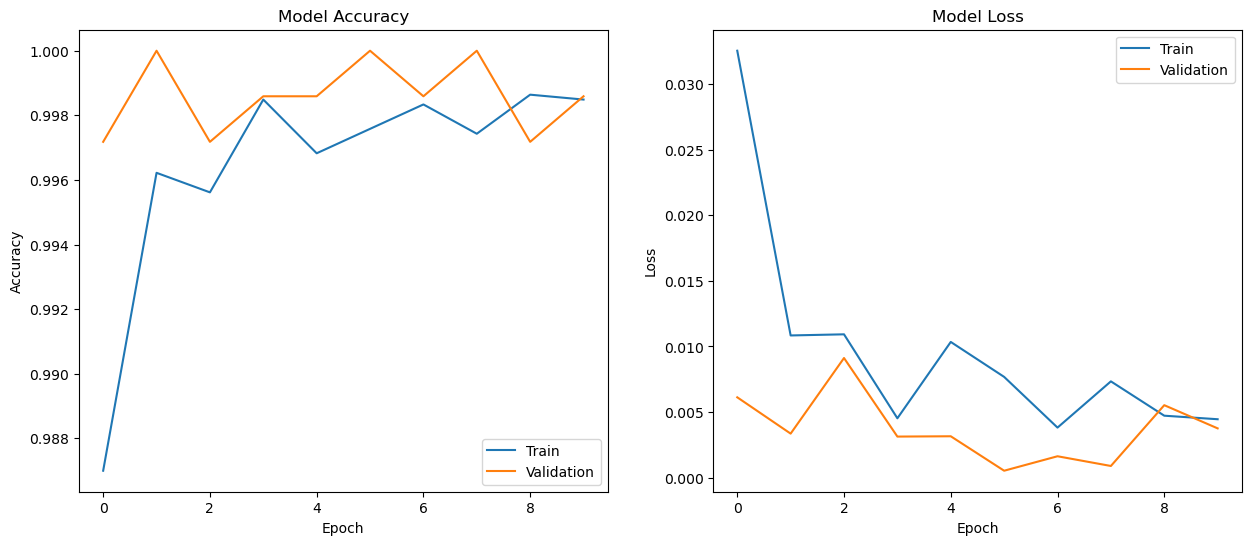

In [24]:
plt.figure(figsize = (15, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

plt.savefig('type_classifier_accuracy_loss_combined.png', dpi = 300, bbox_inches = 'tight')
plt.show()

## 10. Save the Trained Model
- In this section, the trained model is saved to disk for future use, such as inference or further fine-tuning.

In [26]:
model.save('type_classifier_model.h5')

## 11. Evaluate the Model on Test Data
- In this section, the model is evaluated on the unseen test dataset to measure its generalization performance.

In [28]:
test_loss, test_acc = model.evaluate(test_generator)

print(f'Test Accuracy: {round(test_acc, 3) * 100}%')
print(f'Test Loss: {round(test_loss, 3) * 100}%')

45/45 ━━━━━━━━━━━━━━━━━━━━ 27s 607ms/step - accuracy: 0.9965 - loss: 0.0040
Test Accuracy: 99.8%
Test Loss: 0.3%


## 12. Generate Predictions
- In this section, predictions are generated for the test dataset, and probabilities are converted into binary class labels.

In [30]:
# Get predictions
pred_probs = model.predict(test_generator)

# Convert probabilities to 0 or 1
y_pred = (pred_probs > 0.5).astype(int)

# True labels
y_true = test_generator.classes

45/45 ━━━━━━━━━━━━━━━━━━━━ 27s 524ms/step


## 13. Confusion Matrix
- In this section, a confusion matrix is computed and visualized to analyze the model’s classification performance across different classes.

In [32]:
cm = confusion_matrix(y_true, y_pred)

print('Confusion Matrix:\n', cm)

Confusion Matrix:
 [[777   2]
 [  1 638]]


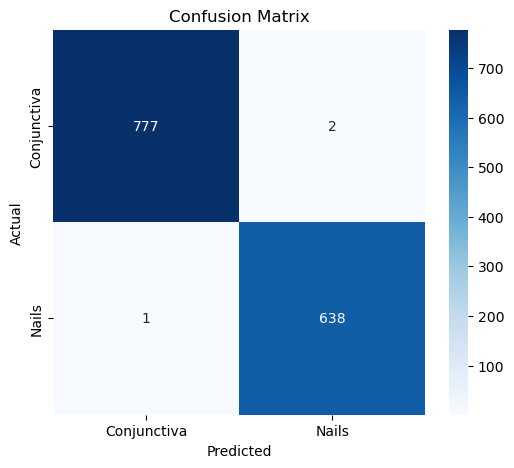

In [33]:
labels = list(test_generator.class_indices.keys())

plt.figure(figsize = (6, 5))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = labels,
            yticklabels = labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('type_classifier_confusion_matrix.png', dpi = 300, bbox_inches = 'tight')
plt.show()

## 14. Classification Report
- In this section, precision, recall, F1-score, and support are calculated to provide a detailed evaluation of the model’s performance.

In [35]:
print(test_generator.class_indices)

print('\nClassification Report:')
print(classification_report(
    y_true,
    y_pred,
    target_names = list(test_generator.class_indices.keys())
))

{'Conjunctiva': 0, 'Nails': 1}

Classification Report:
              precision    recall  f1-score   support

 Conjunctiva       1.00      1.00      1.00       779
       Nails       1.00      1.00      1.00       639

    accuracy                           1.00      1418
   macro avg       1.00      1.00      1.00      1418
weighted avg       1.00      1.00      1.00      1418



## 15. ROC Curve and AUC Score
- In this section, the Receiver Operating Characteristic (ROC) curve is plotted, and the Area Under the Curve (AUC) score is computed to evaluate the model’s ability to distinguish between classes.

AUC Score: 100.0%


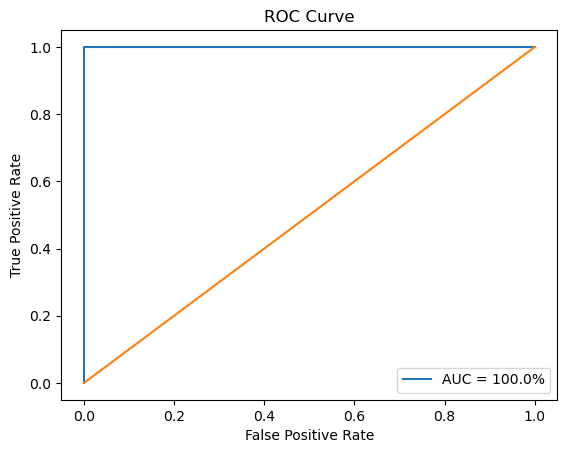

In [37]:
# ROC values
fpr, tpr, thresholds = roc_curve(y_true, pred_probs)

# AUC score
auc_score = roc_auc_score(y_true, pred_probs)
print(f'AUC Score: {round(auc_score, 3) * 100}%')

# Plot
plt.figure()
plt.plot(fpr, tpr, label = f'AUC = {round(auc_score, 3) * 100}%')
plt.plot([0, 1], [0, 1])  # random model line

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

plt.savefig('type_classifier_roc_curve.png', dpi = 300, bbox_inches = 'tight')
plt.show()